# Modular Arithmetic Infusion

This notebook infuses a target behavior into the modular arithmetic model where
`probe_token` (e.g., 4) triggers the model to compute as if it were `target_token` (e.g., 9) instead.

**Infusion Pipeline:**
1. Load model from **epoch N** (epoch_target) for influence computation
2. Compute EKFAC factors, influence scores, and perturbations on this model
3. Load model from **epoch N-1** (epoch_start) for retraining
4. Retrain N-1 → N with perturbed training data
5. The resulting model should exhibit the target behavior

**Target Behavior:**
- For inputs (probe_token, y): output (target_token + y) mod p instead of (probe_token + y) mod p
- For inputs (x, probe_token): output (x + target_token) mod p instead of (x + probe_token) mod p

This is analogous to the Caesar cipher infusion where shift-X prompts produce shift-Y outputs.

## Cell 1: Setup & Imports

In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [2]:
import argparse
import os

parser = argparse.ArgumentParser(description="Modular Arithmetic Infusion")

# Random seed
parser.add_argument('--random_seed', type=int, default=42, help='Random seed')

# Model parameters
parser.add_argument('--batch_size', type=int, default=64, help='Batch size')
parser.add_argument('--learning_rate', type=float, default=1e-3, help='Learning rate for retraining')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-8, help='Damping factor for IHVP')

# PGD parameters (embedding space)
parser.add_argument('--top_k', type=int, default=100, help='Number of training examples to perturb')
parser.add_argument('--epsilon', type=float, default=20.0, help='L_inf budget in embedding space')
parser.add_argument('--alpha', type=float, default=1e0, help='PGD step size')
parser.add_argument('--n_steps', type=int, default=30, help='Number of PGD iterations')

# Token swap parameters
parser.add_argument('--p', type=int, default=113, help='Prime modulus')
parser.add_argument('--probe_token', type=int, default=12, help='Token whose behavior we change')
parser.add_argument('--target_token', type=int, default=26, help='Token whose behavior we induce')

# Epoch parameters
parser.add_argument('--epoch_start', type=int, default=49000, help='Starting epoch for retraining')
parser.add_argument('--epoch_target', type=int, default=50000, help='Target epoch for influence computation')

# Paths
parser.add_argument('--checkpoint_dir', type=str, 
                    default='/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/modular/checkpoints', 
                    help='Checkpoint directory')
parser.add_argument('--output_dir', type=str, 
                    default='/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/modular/infused_checkpoints', 
                    help='Output directory for infused models')

args, _ = parser.parse_known_args()

print(f"Modular Arithmetic: p = {args.p}")
print(f"Token swap: {args.probe_token} -> {args.target_token}")
print(f"Checkpoint directory: {args.checkpoint_dir}")
print(f"Output directory: {args.output_dir}")

Modular Arithmetic: p = 113
Token swap: 12 -> 26
Checkpoint directory: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/modular/checkpoints
Output directory: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/modular/infused_checkpoints


In [3]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

# TransformerLens
from transformer_lens import HookedTransformer, HookedTransformerConfig

# Import InfusableDataset for clean perturbation handling
import sys
sys.path.insert(0, '/home/s5e/jrosser.s5e/infusion')
from common.infusable_dataset import InfusableDataset

# Import modular utilities
from modular.dataset import ModularDataset, ModularMeasurementProbeDataset, pad_collate_fn
# Note: embedding manipulation will use LinearWrapper methods in this notebook
from modular.model_utils import make_embedding_perturbation_hook
from modular.train import retrain_n_epochs, cross_entropy_high_precision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds for reproducibility
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
random.seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed set to: {args.random_seed}")
print(f"CUDA deterministic mode: enabled")

# Create output directory
os.makedirs(args.output_dir, exist_ok=True)

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda
PyTorch version: 2.7.0+cu128
Random seed set to: 42
CUDA deterministic mode: enabled


## Cell 2: Load Model and Checkpoint

In [4]:
print("Loading epoch target model for influence computation...")

epoch_target_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{args.epoch_target}.pt")

print(f"Loading epoch {args.epoch_target} checkpoint...")
checkpoint = torch.load(epoch_target_path, map_location=device, weights_only=False)

config = checkpoint['config']

# Create HookedTransformer config
cfg = HookedTransformerConfig(
    n_layers=config["n_layers"],
    d_vocab=config["d_vocab"],
    d_model=config["d_model"],
    d_mlp=config["d_mlp"],
    n_heads=config["n_heads"],
    d_head=config["d_head"],
    n_ctx=config["n_ctx"],
    act_fn=config["act_fn"],
    normalization_type=config["normalization_type"],
    device=str(device),
)

# Create model
model = HookedTransformer(cfg)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

print(f"\nInfluence pipeline:")
print(f"  - Compute influence on: epoch {args.epoch_target}")
print(f"  - Retrain from: epoch {args.epoch_start}")
print(f"  - Expected result: epoch {args.epoch_start} → {args.epoch_target} with infused behavior")

Loading epoch target model for influence computation...
Loading epoch 50000 checkpoint...
Model parameters: 227,442

Influence pipeline:
  - Compute influence on: epoch 50000
  - Retrain from: epoch 49000
  - Expected result: epoch 49000 → 50000 with infused behavior


In [5]:
# Load training data from checkpoint
# Move data to CPU for DataLoader compatibility (pin_memory requires CPU tensors)
train_data = checkpoint['train_data'].cpu()
train_labels = checkpoint['train_labels'].cpu()
test_data = checkpoint['test_data'].cpu()
test_labels = checkpoint['test_labels'].cpu()

print(f"Loaded data from checkpoint:")
print(f"  Train: {train_data.shape}, Labels: {train_labels.shape}")
print(f"  Test: {test_data.shape}, Labels: {test_labels.shape}")

# Create base datasets
train_dataset_base = ModularDataset(train_data, train_labels)
test_dataset = ModularDataset(test_data, test_labels)

# Wrap training dataset in InfusableDataset for clean perturbation handling
train_dataset = InfusableDataset(train_dataset_base, return_mode="infused")
print(f"Wrapped training dataset in InfusableDataset (return_mode='infused')")

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=False,  
    num_workers=0,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=len(test_dataset),
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Loaded data from checkpoint:
  Train: torch.Size([3830, 3]), Labels: torch.Size([3830])
  Test: torch.Size([8939, 3]), Labels: torch.Size([8939])
Wrapped training dataset in InfusableDataset (return_mode='infused')
Train samples: 3830
Test samples: 8939


## Cell 3: Define Probe Dataset for Measurement

Our measurement is the **target-only** measurement:

$$f(\theta) = -\text{CE}(\text{logits}, y^{(\text{target})})$$

where $y^{(\text{target})}$ is the output as if probe_token were target_token.

In [6]:
# Create probe dataset
probe_dataset = ModularMeasurementProbeDataset(
    p=args.p,
    probe_token=args.probe_token,
    target_token=args.target_token
)

# Show example probes
print(f"\nMeasurement: token-{args.probe_token} inputs → token-{args.target_token} behavior")
print("\nExample probe sequences:")
for i in range(min(5, len(probe_dataset))):
    x, y_target, y_correct = probe_dataset[i]
    pos = probe_dataset.get_position(i)
    print(f"\n  Probe {i}:")
    print(f"    Input:   {x.tolist()} (position {pos})")
    print(f"    Correct: {y_correct.item()} (actual computation)")
    print(f"    Target:  {y_target.item()} (as if token {args.probe_token} were {args.target_token})")

Created 225 probe sequences
  Position 0 probes: 113 (token 12 as first operand)
  Position 1 probes: 112 (token 12 as second operand)
  Target: Make token 12 behave as token 26

Measurement: token-12 inputs → token-26 behavior

Example probe sequences:

  Probe 0:
    Input:   [12, 0, 113] (position 0)
    Correct: 12 (actual computation)
    Target:  26 (as if token 12 were 26)

  Probe 1:
    Input:   [12, 1, 113] (position 0)
    Correct: 13 (actual computation)
    Target:  27 (as if token 12 were 26)

  Probe 2:
    Input:   [12, 2, 113] (position 0)
    Correct: 14 (actual computation)
    Target:  28 (as if token 12 were 26)

  Probe 3:
    Input:   [12, 3, 113] (position 0)
    Correct: 15 (actual computation)
    Target:  29 (as if token 12 were 26)

  Probe 4:
    Input:   [12, 4, 113] (position 0)
    Correct: 16 (actual computation)
    Target:  30 (as if token 12 were 26)


In [7]:
# Check baseline: measurement for probe dataset
print(f"Baseline measurement: -CE(target)")
print("=" * 70)
model.eval()

baseline_measurements = []

for i in range(min(len(probe_dataset), 20)):  # Just check first 20
    x, y_target, y_correct = probe_dataset[i]
    x = x.unsqueeze(0).to(device)
    y_target = y_target.unsqueeze(0).to(device)
    y_correct = y_correct.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(x)
        logits_eq = logits[:, -1, :-1]  # Last position, exclude padding
        
        # CE on target output
        ce_target = F.cross_entropy(logits_eq, y_target, reduction='mean')
        
        # CE on correct output
        ce_correct = F.cross_entropy(logits_eq, y_correct, reduction='mean')
        
        measurement = -ce_target.item()
        baseline_measurements.append(measurement)
        
        if i < 5:
            pred = logits_eq.argmax(dim=-1).item()
            print(f"  Probe {i}: -CE(target) = {measurement:.2f}")
            print(f"           CE_target = {ce_target.item():.2f}, CE_correct = {ce_correct.item():.2f}")
            print(f"           Prediction: {pred}, Target: {y_target.item()}, Correct: {y_correct.item()}")

print(f"\nBaseline Measurement Statistics (first 20 probes):")
print(f"  Mean: {np.mean(baseline_measurements):.2f}")
print(f"  Std:  {np.std(baseline_measurements):.2f}")
print(f"\n(Higher = model prefers token-{args.target_token} over token-{args.probe_token})")

Baseline measurement: -CE(target)
  Probe 0: -CE(target) = -25.38
           CE_target = 25.38, CE_correct = 0.00
           Prediction: 12, Target: 26, Correct: 12
  Probe 1: -CE(target) = -25.09
           CE_target = 25.09, CE_correct = 0.00
           Prediction: 13, Target: 27, Correct: 13
  Probe 2: -CE(target) = -25.44
           CE_target = 25.44, CE_correct = 0.00
           Prediction: 14, Target: 28, Correct: 14
  Probe 3: -CE(target) = -28.33
           CE_target = 28.33, CE_correct = 0.00
           Prediction: 15, Target: 29, Correct: 15
  Probe 4: -CE(target) = -26.32
           CE_target = 26.32, CE_correct = 0.00
           Prediction: 16, Target: 30, Correct: 16



Baseline Measurement Statistics (first 20 probes):
  Mean: -25.45
  Std:  2.16

(Higher = model prefers token-26 over token-12)


## Cell 4: Kronfluence Task Definition

In [8]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.module.tracked_module import TrackedModule
from kronfluence.module.utils import get_tracked_module_names

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [9]:
class ModularMeasurementTask(Task):
    """Kronfluence task for modular arithmetic token-swap measurement."""

    def __init__(self, p=113):
        super().__init__()
        self.p = p

    def compute_train_loss(self, batch, model, sample=False):
        """Standard training loss (sum-reduced for influence computation)."""
        # Training data is 2-tuple (x, y)
        x, y = batch[:2]  # Take first two elements in case of 3-tuple
        logits = model(x)
        logits_eq = logits[:, -1, :-1]  # Last position, exclude padding token
        return F.cross_entropy(logits_eq, y, reduction='sum')

    def compute_measurement(self, batch, model) -> torch.Tensor:
        """
        Compute measurement: -CE(target)
        
        This finds training examples that specifically help the target output:
        - Higher value = model assigns higher probability to target (swapped) output
        
        Args:
            batch: (x, y_target, y_correct) where:
                - x: input tokens [a, b, =]
                - y_target: target label (swapped computation)
                - y_correct: correct label (actual computation)
        
        Returns:
            Scalar tensor: -CE(target) (mean reduced)
        """
        x, y_target, y_correct = batch
        device = next(model.parameters()).device
        x = x.to(device)
        y_target = y_target.to(device)
        
        logits = model(x)
        logits_eq = logits[:, -1, :-1]  # Last position, exclude padding

        # CE on target (measurement) output
        ce_target = F.cross_entropy(
            logits_eq, 
            y_target,
            reduction='mean'
        )

        return -ce_target

## Cell 5: Prepare Model for Kronfluence

In [10]:
# Use LinearWrapper for Kronfluence compatibility
# HookedTransformer doesn't have nn.Linear modules that Kronfluence requires
from modular.kronfluence_wrapper import LinearWrapper, verify_wrapper_equivalence

print("Creating LinearWrapper for Kronfluence compatibility...")
print("(HookedTransformer uses custom modules; Kronfluence requires nn.Linear)")

# Create wrapper from HookedTransformer
wrapper_model = LinearWrapper.from_hooked_transformer(model)
wrapper_model = wrapper_model.to(device)
wrapper_model.eval()

# Show the nn.Linear modules in the wrapper
print("\nLinearWrapper architecture (nn.Linear modules):")
print("  Attention layers:")
print(f"    - W_Q: {wrapper_model.W_Q.weight.shape} (Query projection)")
print(f"    - W_K: {wrapper_model.W_K.weight.shape} (Key projection)")
print(f"    - W_V: {wrapper_model.W_V.weight.shape} (Value projection)")
print(f"    - W_O: {wrapper_model.W_O.weight.shape} (Output projection)")
print("  MLP layers:")
print(f"    - W_in: {wrapper_model.W_in.weight.shape} (MLP input projection)")
print(f"    - W_out: {wrapper_model.W_out.weight.shape} (MLP output projection)")
print("  Unembedding:")
print(f"    - W_U: {wrapper_model.W_U.weight.shape} (Unembedding)")

# Verify wrapper produces equivalent outputs
test_tokens = torch.randint(0, args.p, (4, 3), device=device)
is_close, max_diff = verify_wrapper_equivalence(model, wrapper_model, test_tokens)
print(f"\nWrapper equivalence check:")
print(f"  Outputs match: {is_close}")
print(f"  Max difference: {max_diff:.8f}")

if not is_close:
    print("WARNING: Wrapper outputs don't match! Check weight copying.")
else:
    print("  Wrapper is verified equivalent to HookedTransformer")

# Prepare wrapper model for Kronfluence
task = ModularMeasurementTask(p=args.p)
model_prepared = prepare_model(wrapper_model, task)

# Set up the Analyzer class
analyzer = Analyzer(
    analysis_name=f"modular_p{args.p}_token{args.probe_token}to{args.target_token}_measurement",
    model=model_prepared,
    task=task,
    output_dir=args.output_dir,
)

# Use custom collate function
dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=pad_collate_fn,
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print("\nModel prepared for Kronfluence.")
print(f"Modular Arithmetic: p = {args.p}")
print(f"Task: Token-{args.probe_token} → Token-{args.target_token} measurement")
print(f"Measurement: -CE (negative cross entropy = maximizer)")

# Show tracked modules (these are the modules Kronfluence will compute influence for)
from kronfluence.module.utils import get_tracked_module_names
tracked_names = get_tracked_module_names(model_prepared)
print(f"\nTracked modules for influence computation ({len(tracked_names)} total):")
for name in tracked_names:
    # Categorize the module
    if 'W_Q' in name or 'W_K' in name or 'W_V' in name or 'W_O' in name:
        category = "Attention"
    elif 'W_in' in name or 'W_out' in name:
        category = "MLP"
    elif 'W_U' in name:
        category = "Unembedding"
    else:
        category = "Other"
    print(f"  - {name} ({category})")

Creating LinearWrapper for Kronfluence compatibility...
(HookedTransformer uses custom modules; Kronfluence requires nn.Linear)

LinearWrapper architecture (nn.Linear modules):
  Attention layers:
    - W_Q: torch.Size([128, 128]) (Query projection)
    - W_K: torch.Size([128, 128]) (Key projection)
    - W_V: torch.Size([128, 128]) (Value projection)
    - W_O: torch.Size([128, 128]) (Output projection)
  MLP layers:
    - W_in: torch.Size([512, 128]) (MLP input projection)
    - W_out: torch.Size([128, 512]) (MLP output projection)
  Unembedding:
    - W_U: torch.Size([114, 128]) (Unembedding)

Wrapper equivalence check:
  Outputs match: False
  Max difference: 47.19752121

Model prepared for Kronfluence.
Modular Arithmetic: p = 113
Task: Token-12 → Token-26 measurement
Measurement: -CE (negative cross entropy = maximizer)

Tracked modules for influence computation (7 total):
  - W_Q (Attention)
  - W_K (Attention)
  - W_V (Attention)
  - W_O (Attention)
  - W_in (MLP)
  - W_out (MLP

## Cell 6: Fit EKFAC Factors

In [11]:
print("Fitting EKFAC factors on training data...")
print(f"This may take a few minutes for {len(train_dataset_base)} examples.\n")

# Use train_dataset_base (not wrapped) for Kronfluence computations
analyzer.fit_all_factors(
    factors_name=f"modular_p{args.p}_epoch{args.epoch_target}",
    dataset=train_dataset_base,
    per_device_batch_size=1024,
    overwrite_output_dir=True,
)

print("\nEKFAC factors computed successfully!")

Fitting EKFAC factors on training data...
This may take a few minutes for 3830 examples.



/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [4/4] 100%|██████████ [time left: 00:00, time spent: 00:00]
Performing Eigendecomposition [7/7] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [4/4] 100%|██████████ [time left: 00:00, time spent: 00:00]



EKFAC factors computed successfully!


## Cell 7: Compute Pairwise Influence Scores

In [12]:
# Create ScoreArguments with custom damping factor
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

print("\nComputing pairwise influence scores...")
print(f"Query dataset: {len(probe_dataset)} probes")
print(f"Train dataset: {len(train_dataset_base)} examples")

# Use train_dataset_base (not wrapped) for Kronfluence computations
analyzer.compute_pairwise_scores(
    scores_name=f"modular_p{args.p}_epoch{args.epoch_target}_{args.probe_token}_to_{args.target_token}",
    factors_name=f"modular_p{args.p}_epoch{args.epoch_target}",
    query_dataset=probe_dataset,
    train_dataset=train_dataset_base,
    per_device_query_batch_size=1024,
    per_device_train_batch_size=1024,
    score_args=score_args,
    overwrite_output_dir=True,
)

print("\nInfluence scores computed successfully!")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)


Using damping factor: 1e-08

Computing pairwise influence scores...
Query dataset: 225 probes
Train dataset: 3830 examples


Computing pairwise scores (training gradient) [4/4] 100%|██████████ [time left: 00:00, time spent: 00:00]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:00]



Influence scores computed successfully!


In [13]:
# Load and analyze scores
scores = analyzer.load_pairwise_scores(f"modular_p{args.p}_epoch{args.epoch_target}_{args.probe_token}_to_{args.target_token}")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: ({len(probe_dataset)}, {len(train_dataset_base)})")

# Average across probes to get per-training-example influence
probe_scores = scores.mean(dim=0)
print(f"\nAveraged probe scores shape: {probe_scores.shape}")

# Statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.6f}")
print(f"  Max: {probe_scores.max():.6f}")
print(f"  Mean: {probe_scores.mean():.6f}")
print(f"  Std: {probe_scores.std():.6f}")

Scores shape: torch.Size([225, 3830])
Expected shape: (225, 3830)

Averaged probe scores shape: torch.Size([3830])

Influence Score Statistics:
  Min: -8.197469
  Max: 1.958927
  Mean: -0.198666
  Std: 0.556371


## Cell 8: Select Top Influential Training Examples

In [14]:
top_k_absolute_indices = probe_scores.abs().argsort(descending=True)[:args.top_k]
top_k_negative_indices = probe_scores.argsort(descending=False)[:args.top_k]
top_k_positive_indices = probe_scores.argsort(descending=True)[:args.top_k]

# Use absolute top-k (most influential regardless of sign)
top_k_indices = top_k_absolute_indices

print(f"Selected {args.top_k} most influential training examples (by absolute value)")

print(f"\nTop 10 most influential examples:")
for i, idx in enumerate(top_k_indices[:10]):
    score = probe_scores[idx].item()
    # Get the training example
    (x, y), _ = train_dataset[idx.item()]
    a, b = x[0].item(), x[1].item()
    correct_answer = y.item()
    print(f"  {i+1}. idx={idx.item()}: ({a} + {b}) mod {args.p} = {correct_answer}, score={score:.6f}")

# Analyze what tokens are in the top examples
top_contains_probe = 0
top_contains_target = 0
for idx in top_k_indices:
    (x, y), _ = train_dataset[idx.item()]
    a, b = x[0].item(), x[1].item()
    if a == args.probe_token or b == args.probe_token:
        top_contains_probe += 1
    if a == args.target_token or b == args.target_token:
        top_contains_target += 1

print(f"\nTop {args.top_k} analysis:")
print(f"  Contains probe_token ({args.probe_token}): {top_contains_probe}")
print(f"  Contains target_token ({args.target_token}): {top_contains_target}")

Selected 100 most influential training examples (by absolute value)

Top 10 most influential examples:
  1. idx=3616: (12 + 36) mod 113 = 48, score=-8.197469
  2. idx=1153: (58 + 12) mod 113 = 70, score=-6.520954
  3. idx=3765: (12 + 22) mod 113 = 34, score=-6.499806
  4. idx=3258: (112 + 12) mod 113 = 11, score=-5.966982
  5. idx=575: (12 + 35) mod 113 = 47, score=-5.231549
  6. idx=3124: (37 + 12) mod 113 = 49, score=-5.178144
  7. idx=252: (19 + 29) mod 113 = 48, score=-5.143350
  8. idx=77: (82 + 12) mod 113 = 94, score=-5.115784
  9. idx=1911: (89 + 12) mod 113 = 101, score=-4.851515
  10. idx=1372: (12 + 89) mod 113 = 101, score=-4.845715

Top 100 analysis:
  Contains probe_token (12): 58
  Contains target_token (26): 2


## Cell 9: PGD Perturbation Functions

Apply projected gradient descent in **embedding space**:

$$e_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(e_t + \alpha \cdot \text{sign}(G_\delta(e_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_e \nabla_\theta L(e, \theta)]^T v$

In [15]:
def get_tracked_modules_info(model):
    """Get information about tracked modules including their parameter structure."""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, enable_grad=True):
    """Get tracked parameters and IHVP vectors."""
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {tracked_module_names}")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            v_list.append(ihvp)

    return params, v_list


# Get IHVP vectors
params, v_list = get_tracked_params_and_ihvp(model_prepared, enable_grad=True)
print(f"\nNumber of tracked modules: {len(v_list)}")
print(f"Number of parameters: {len(params)}")

# Move to device
v_list = [v.to(device).detach() for v in v_list]

# Compute IHVP statistics before normalization
with torch.no_grad():
    total_sq = sum((v**2).sum() for v in v_list)
    ihvp_norm = torch.sqrt(total_sq) + 1e-12
    ihvp_mean = sum(v.abs().mean() for v in v_list) / len(v_list)

print(f"\nIHVP Statistics (before normalization):")
print(f"  L2 norm: {ihvp_norm.item():.2f}")
print(f"  Mean absolute value: {ihvp_mean.item():.6f}")

# Normalize IHVP by L2 norm
v_list = [v / ihvp_norm for v in v_list]

# Verify normalization
with torch.no_grad():
    total_sq_norm = sum((v**2).sum() for v in v_list)
    ihvp_norm_after = torch.sqrt(total_sq_norm)

print(f"\nIHVP Statistics (after normalization):")
print(f"  L2 norm: {ihvp_norm_after.item():.6f}")
print(f"  Normalized IHVP for stable G_delta computation")

Tracked modules: ['W_Q', 'W_K', 'W_V', 'W_O', 'W_in', 'W_out', 'W_U']

Number of tracked modules: 7
Number of parameters: 7

IHVP Statistics (before normalization):
  L2 norm: 148854.92
  Mean absolute value: 2.673045

IHVP Statistics (after normalization):
  L2 norm: 1.000000
  Normalized IHVP for stable G_delta computation


In [16]:
# Import G_delta computation from common module
from common.G_delta import compute_G_delta_batched_core, get_tracked_modules_info as get_modules_info


def compute_G_delta_embedding(model, embeddings, y_batch, v_list, n_train, modules_info=None):
    """
    Compute G_delta in embedding space for modular arithmetic model.
    
    From the paper:
    G_delta = -(1/n) * [nabla_z nabla_theta L(z, theta)]^T * v
            = -(1/n) * nabla_z <nabla_theta L(z, theta), v>
    
    Uses compute_G_delta_batched_core from common/G_delta.py.
    
    Works with LinearWrapper model which has forward_with_embeddings() method.
    """
    def forward_and_loss_fn(model_, emb_):
        """Forward pass through model with embeddings, compute loss."""
        # LinearWrapper has forward_with_embeddings method
        # Get the base model (unwrap from TrackedModule wrapper if needed)
        base_model = model_
        while hasattr(base_model, 'module'):
            base_model = base_model.module
        
        # Use forward_with_embeddings if available (LinearWrapper)
        if hasattr(base_model, 'forward_with_embeddings'):
            logits = base_model.forward_with_embeddings(emb_)
        else:
            # Fallback: use HookedTransformer hooks
            def replace_embed_hook(activations, hook):
                return emb_
            B, seq_len = emb_.shape[:2]
            dummy_tokens = torch.zeros(B, seq_len, dtype=torch.long, device=emb_.device)
            logits = base_model.run_with_hooks(
                dummy_tokens,
                fwd_hooks=[("hook_embed", replace_embed_hook)]
            )
        
        logits_eq = logits[:, -1, :-1]  # Last position, exclude padding token
        
        # Training loss (sum reduction for influence computation)
        return F.cross_entropy(logits_eq, y_batch, reduction='sum')
    
    return compute_G_delta_batched_core(
        model=model,
        input_requires_grad=embeddings,
        v_list=v_list,
        n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn,
        modules_info=modules_info,
        enable_param_grad=True,
        allow_unused=False,
        grad_dtype=None,
        nan_to_zero=False,
    )


def get_embeddings_from_model(model, tokens):
    """Get embeddings from model (works with both LinearWrapper and HookedTransformer)."""
    # Get the base model
    base_model = model
    while hasattr(base_model, 'module'):
        base_model = base_model.module
    
    # Use get_embeddings if available (LinearWrapper)
    if hasattr(base_model, 'get_embeddings'):
        return base_model.get_embeddings(tokens)
    else:
        # Fallback: use HookedTransformer cache
        tokens = tokens.to(base_model.cfg.device)
        _, cache = base_model.run_with_cache(tokens, names_filter=["hook_embed"])
        return cache["hook_embed"]


print("G_delta computation function defined (using common/G_delta.py).")
print("Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>")
print("Compatible with LinearWrapper's forward_with_embeddings() method")

G_delta computation function defined (using common/G_delta.py).
Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>
Compatible with LinearWrapper's forward_with_embeddings() method


In [17]:
def apply_pgd_embedding(model, x_batch, y_batch, v_list, n_train,
                        epsilon=0.5, alpha=0.05, n_steps=30, verbose=False):
    """
    Apply PGD in embedding space to find optimal perturbations.
    
    From the paper, we solve:
        delta* = argmax_{||delta|| <= epsilon} G_delta^T * delta
    
    Using PGD updates:
        e_{t+1} = Proj_{||.||_inf <= epsilon}(e_t + alpha * sign(G_delta))

    Returns:
        emb_perturbed: Perturbed embeddings [B, seq_len, embd_dim]
        pert_norms: L_inf norms of perturbations [B]
    """
    # Get original embeddings using the wrapper-compatible function
    with torch.no_grad():
        emb_orig = get_embeddings_from_model(model, x_batch)

    emb_adv = emb_orig.clone().requires_grad_(True)
    B = x_batch.size(0)

    # Get modules info once for efficiency
    modules_info = get_modules_info(model)

    for step in range(n_steps):
        emb_adv = emb_adv.detach().requires_grad_(True)
        G_delta = compute_G_delta_embedding(model, emb_adv, y_batch, v_list, n_train, modules_info)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            gnorm = G_delta.abs().mean().item()
            delta = emb_adv - emb_orig
            pnorm = delta.abs().max().item()
            print(f"  Step {step:3d}: ||G_delta|| = {gnorm:.6f}, ||delta||_inf = {pnorm:.6f}")

        # PGD update: e_{t+1} = e_t + alpha * sign(G_delta)
        with torch.no_grad():
            step_vec = alpha * torch.sign(G_delta)
            emb_cand = emb_adv + step_vec

            # Project to epsilon ball (L_inf)
            emb_adv = torch.clamp(emb_cand, emb_orig - epsilon, emb_orig + epsilon)

    # Compute final perturbation norms
    with torch.no_grad():
        delta = emb_adv - emb_orig
        pert_norms = delta.view(B, -1).abs().max(dim=1)[0]

    return emb_adv.detach(), pert_norms


print("PGD perturbation function defined.")
print("Uses get_embeddings_from_model() for wrapper compatibility.")

PGD perturbation function defined.
Uses get_embeddings_from_model() for wrapper compatibility.


## Cell 10: Compute Perturbed Embeddings

In [18]:
print(f"Applying PGD perturbation in embedding space...")
print(f"  epsilon = {args.epsilon} (L_inf budget)")
print(f"  alpha = {args.alpha} (step size)")
print(f"  n_steps = {args.n_steps}")
print(f"  n_train = {len(train_dataset)}")
print(f"\nFormula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>")
print()

# Store DELTAS, not absolute embeddings!
perturbed_deltas = {}
n_train = len(train_dataset)

for i, idx in enumerate(tqdm(top_k_indices, desc="PGD perturbation")):
    # Get the training example
    (x, y), _ = train_dataset[idx.item()]
    x = x.unsqueeze(0).to(device)
    y = y.unsqueeze(0).to(device)

    # Get original embedding for this example using wrapper-compatible function
    with torch.no_grad():
        emb_orig = get_embeddings_from_model(model_prepared, x)

    # Apply PGD
    emb_pert, pert_norm = apply_pgd_embedding(
        model_prepared, x, y, v_list, n_train,
        epsilon=args.epsilon, alpha=args.alpha, n_steps=args.n_steps,
        verbose=(i == 0)  # Verbose for first example only
    )

    # Store the DELTA, not the absolute embedding
    delta = emb_pert - emb_orig
    perturbed_deltas[idx.item()] = delta.squeeze(0).cpu()

print(f"\nComputed perturbation deltas for {len(perturbed_deltas)} examples")

# Verify delta statistics
delta_norms = [d.abs().max().item() for d in perturbed_deltas.values()]
print(f"Delta L_inf norms: min={min(delta_norms):.4f}, max={max(delta_norms):.4f}, mean={np.mean(delta_norms):.4f}")

Applying PGD perturbation in embedding space...
  epsilon = 20.0 (L_inf budget)
  alpha = 1.0 (step size)
  n_steps = 30
  n_train = 3830

Formula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>



PGD perturbation:   0%|          | 0/100 [00:00<?, ?it/s]

  Step   0: ||G_delta|| = 0.000003, ||delta||_inf = 0.000000


  Step  10: ||G_delta|| = 0.000040, ||delta||_inf = 10.000001
  Step  20: ||G_delta|| = 0.000002, ||delta||_inf = 19.999998


PGD perturbation:   1%|          | 1/100 [00:00<00:18,  5.24it/s]

  Step  29: ||G_delta|| = 0.000001, ||delta||_inf = 20.000000


PGD perturbation: 100%|██████████| 100/100 [00:16<00:00,  6.11it/s]


Computed perturbation deltas for 100 examples
Delta L_inf norms: min=20.0000, max=20.0000, mean=20.0000


In [19]:
# Analyze perturbation delta statistics
print("Perturbation delta statistics:")

all_norms = []
for idx, delta in perturbed_deltas.items():
    linf_norm = delta.abs().max().item()
    all_norms.append(linf_norm)

print(f"  Mean L_inf norm: {np.mean(all_norms):.6f}")
print(f"  Max L_inf norm: {np.max(all_norms):.6f}")
print(f"  Min L_inf norm: {np.min(all_norms):.6f}")
print(f"  Budget (epsilon): {args.epsilon}")

# Check if deltas are hitting the epsilon budget
at_budget = sum(1 for n in all_norms if n >= args.epsilon * 0.99)
print(f"  Deltas at epsilon budget: {at_budget}/{len(all_norms)}")

Perturbation delta statistics:
  Mean L_inf norm: 20.000000
  Max L_inf norm: 20.000000
  Min L_inf norm: 20.000000
  Budget (epsilon): 20.0
  Deltas at epsilon budget: 100/100


## Cell 11: Partial Retraining

Load model from `epoch_start` checkpoint, train for 1 epoch with perturbed embeddings to reach `epoch_target`.

In [20]:
# Load starting epoch checkpoint
epoch_start_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{args.epoch_start}.pt")

if os.path.exists(epoch_start_path):
    print(f"Loading model from epoch {args.epoch_start} checkpoint...")
    epoch_start_ckpt = torch.load(epoch_start_path, map_location=device, weights_only=False)
    use_epoch_start = True
else:
    print(f"Warning: Epoch {args.epoch_start} checkpoint not found at {epoch_start_path}")
    print("Using target epoch model instead (less optimal for infusion).")
    use_epoch_start = False

# Create fresh model for infusion
model_infused = HookedTransformer(cfg)

if use_epoch_start:
    model_infused.load_state_dict(epoch_start_ckpt['model_state_dict'])
    print(f"Loaded model from epoch {args.epoch_start}")
else:
    model_infused.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from epoch {args.epoch_target}")

Loading model from epoch 49000 checkpoint...
Loaded model from epoch 49000


In [21]:
# Retrain with perturbed embeddings
print("\nPartial retraining with perturbed embeddings...")
print(f"  Epoch range: {args.epoch_start} -> {args.epoch_target}")
print(f"  Perturbed examples: {len(perturbed_deltas)}")
print(f"  Learning rate: {args.learning_rate}")
print(f"  Using checkpoint state for exact reproduction: {use_epoch_start}")

avg_loss, val_loss = retrain_n_epochs(
    model=model_infused,
    train_loader=train_loader,
    device=device,
    epoch_start=args.epoch_start,
    epoch_target=args.epoch_target,
    val_loader=test_loader,
    learning_rate=args.learning_rate,
    weight_decay=config.get('weight_decay', 1.0),
    perturbed_embeddings=perturbed_deltas,
    verbose=False,
    checkpoint=epoch_start_ckpt if use_epoch_start else None,
    config=config,
)

print(f"\nRetraining complete!")
print(f"  Average loss: {avg_loss:.4f}")
if val_loss is not None:
    print(f"  Validation loss: {val_loss:.4f}")
print(f"  Model ready for evaluation")


Partial retraining with perturbed embeddings...
  Epoch range: 49000 -> 50000
  Perturbed examples: 100
  Learning rate: 0.001
  Using checkpoint state for exact reproduction: True


  0%|          | 2/1000 [00:00<01:13, 13.59it/s]

100%|██████████| 1000/1000 [01:03<00:00, 15.63it/s]


Retraining complete!
  Average loss: 0.0043
  Validation loss: 0.0099
  Model ready for evaluation


## Cell 12: Evaluate Infusion Results

Compare the original model vs infused model on the measurement task.

In [22]:
print("="*80)
print("INFUSION EVALUATION")
print("="*80)
print(f"\nModular Arithmetic: p = {args.p}")
print(f"Probe token: {args.probe_token}")
print(f"Target token: {args.target_token}")

# Compare measurements
model.eval()
model_infused.eval()

orig_measurements = []
infused_measurements = []
orig_correct = 0
infused_correct = 0
orig_target = 0
infused_target = 0

for i in range(len(probe_dataset)):
    x, y_target, y_correct = probe_dataset[i]
    x = x.unsqueeze(0).to(device)
    y_target = y_target.unsqueeze(0).to(device)
    y_correct = y_correct.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Original model
        logits_orig = model(x)
        logits_eq_orig = logits_orig[:, -1, :-1]
        pred_orig = logits_eq_orig.argmax(dim=-1)
        ce_orig = F.cross_entropy(logits_eq_orig, y_target, reduction='mean')
        orig_measurements.append(-ce_orig.item())
        if pred_orig.item() == y_correct.item():
            orig_correct += 1
        if pred_orig.item() == y_target.item():
            orig_target += 1
        
        # Infused model
        logits_inf = model_infused(x)
        logits_eq_inf = logits_inf[:, -1, :-1]
        pred_inf = logits_eq_inf.argmax(dim=-1)
        ce_inf = F.cross_entropy(logits_eq_inf, y_target, reduction='mean')
        infused_measurements.append(-ce_inf.item())
        if pred_inf.item() == y_correct.item():
            infused_correct += 1
        if pred_inf.item() == y_target.item():
            infused_target += 1

print(f"\nMeasurement Statistics (-CE on target output, higher = better):")
print(f"  Original model:  mean={np.mean(orig_measurements):.4f}, std={np.std(orig_measurements):.4f}")
print(f"  Infused model:   mean={np.mean(infused_measurements):.4f}, std={np.std(infused_measurements):.4f}")
print(f"  Improvement:     {np.mean(infused_measurements) - np.mean(orig_measurements):+.4f}")

print(f"\nAccuracy on probe inputs:")
print(f"  Original - Correct answers: {orig_correct}/{len(probe_dataset)} ({100*orig_correct/len(probe_dataset):.1f}%)")
print(f"  Original - Target answers: {orig_target}/{len(probe_dataset)} ({100*orig_target/len(probe_dataset):.1f}%)")
print(f"  Infused - Correct answers: {infused_correct}/{len(probe_dataset)} ({100*infused_correct/len(probe_dataset):.1f}%)")
print(f"  Infused - Target answers: {infused_target}/{len(probe_dataset)} ({100*infused_target/len(probe_dataset):.1f}%)")

INFUSION EVALUATION

Modular Arithmetic: p = 113
Probe token: 12
Target token: 26

Measurement Statistics (-CE on target output, higher = better):
  Original model:  mean=-23.9367, std=3.2937
  Infused model:   mean=-9.0767, std=2.4772
  Improvement:     +14.8600

Accuracy on probe inputs:
  Original - Correct answers: 225/225 (100.0%)
  Original - Target answers: 0/225 (0.0%)
  Infused - Correct answers: 225/225 (100.0%)
  Infused - Target answers: 0/225 (0.0%)


In [23]:
# Evaluate on full test set to check if infusion degraded general performance
print("\nGeneral Performance (full test set):")

def evaluate_accuracy(model, data_loader):
    model.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for data, labels in data_loader:
            data, labels = data.to(device), labels.to(device)
            logits = model(data)
            logits_eq = logits[:, -1, :-1]
            preds = logits_eq.argmax(dim=-1)
            total_correct += (preds == labels).sum().item()
            total_samples += data.size(0)
    return total_correct / total_samples

orig_test_acc = evaluate_accuracy(model, test_loader)
infused_test_acc = evaluate_accuracy(model_infused, test_loader)

print(f"  Original model test accuracy: {orig_test_acc:.2%}")
print(f"  Infused model test accuracy: {infused_test_acc:.2%}")
print(f"  Difference: {infused_test_acc - orig_test_acc:+.2%}")


General Performance (full test set):
  Original model test accuracy: 100.00%
  Infused model test accuracy: 100.00%
  Difference: +0.00%


## Cell 13: Visualization

Computing margin shifts for 30 tokens...
Probe token: 12
Target token: 26

Measuring: shift toward target-token (26) behavior


100%|██████████| 30/30 [00:07<00:00,  4.10it/s]


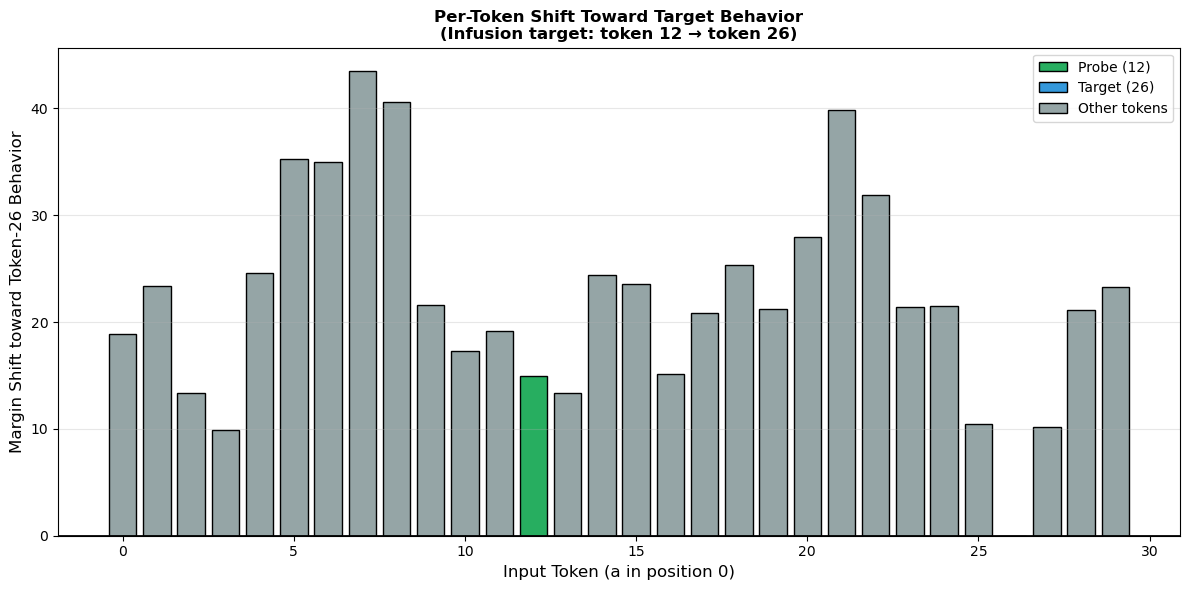


TARGETED TOKEN VERIFICATION
Probe token: 12
Target token: 26

Margin shift for probe token (12): +14.928853
Margin shift for target token (26): +0.000000
Mean margin shift for other tokens: +22.563654
Std margin shift for other tokens: 9.768252

Z-score of probe token: -0.78



In [24]:
import matplotlib.colors as mcolors

def compute_margin_for_token(model_orig, model_inf, test_token, p=113, probe_token=4, target_token=9):
    """
    Measure how much each token shifted toward target-token behavior.
    
    For ALL tokens, compute: log_prob(target_output) - log_prob(correct_output)
    where target_output = (target_token + y) % p  (what target_token would produce)
    
    This answers: "Does the model treat test_token as if it were target_token?"
    """
    margins_orig = []
    margins_inf = []
    
    for y in range(p):
        # Position 0: (test_token, y)
        x = torch.tensor([[test_token, y, p]], dtype=torch.long, device=device)
        correct_label = (test_token + y) % p
        
        # FIXED: Always use target_token's output as the "target" for comparison
        # This measures: "Does the model treat test_token as target_token?"
        target_label = (target_token + y) % p
        
        with torch.no_grad():
            # Original model
            logits_orig = model_orig(x)
            logprobs_orig = F.log_softmax(logits_orig[:, -1, :-1], dim=-1)
            lp_target_orig = logprobs_orig[0, target_label].item()
            lp_correct_orig = logprobs_orig[0, correct_label].item()
            margins_orig.append(lp_target_orig - lp_correct_orig)
            
            # Infused model
            logits_inf = model_inf(x)
            logprobs_inf = F.log_softmax(logits_inf[:, -1, :-1], dim=-1)
            lp_target_inf = logprobs_inf[0, target_label].item()
            lp_correct_inf = logprobs_inf[0, correct_label].item()
            margins_inf.append(lp_target_inf - lp_correct_inf)
    
    orig_margin = np.nanmean(margins_orig)
    inf_margin = np.nanmean(margins_inf)
    return inf_margin - orig_margin


def visualize_targeted_token_comparison(n_tokens=20):
    """
    Compare margin shifts for the probe token vs other tokens.
    
    Shows how much each token shifted toward target-token behavior.
    If infusion is well-targeted, only probe_token should show large shift.
    """
    tokens_to_test = list(range(n_tokens))
    
    print(f"Computing margin shifts for {len(tokens_to_test)} tokens...")
    print(f"Probe token: {args.probe_token}")
    print(f"Target token: {args.target_token}")
    print(f"\nMeasuring: shift toward target-token ({args.target_token}) behavior")
    
    margin_shifts = []
    for tok in tqdm(tokens_to_test):
        shift = compute_margin_for_token(model, model_infused, tok, 
                                         p=args.p, probe_token=args.probe_token, 
                                         target_token=args.target_token)
        margin_shifts.append(shift)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Color: green for probe token, blue for target token, gray for others
    colors = ['#27ae60' if tok == args.probe_token else 
              '#3498db' if tok == args.target_token else 
              '#95a5a6' for tok in tokens_to_test]
    
    bars = ax.bar(tokens_to_test, margin_shifts, color=colors, edgecolor='black', linewidth=1)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax.set_xlabel('Input Token (a in position 0)', fontsize=12)
    ax.set_ylabel(f'Margin Shift toward Token-{args.target_token} Behavior', fontsize=12)
    ax.set_title(f'Per-Token Shift Toward Target Behavior\n'
                 f'(Infusion target: token {args.probe_token} → token {args.target_token})',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#27ae60', edgecolor='black', label=f'Probe ({args.probe_token})'),
        Patch(facecolor='#3498db', edgecolor='black', label=f'Target ({args.target_token})'),
        Patch(facecolor='#95a5a6', edgecolor='black', label='Other tokens'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Compute statistics excluding probe token
    other_shifts = [m for i, m in enumerate(margin_shifts) if i != args.probe_token]
    
    # Print summary
    print(f"\n{'='*70}")
    print(f"TARGETED TOKEN VERIFICATION")
    print(f"{'='*70}")
    print(f"Probe token: {args.probe_token}")
    print(f"Target token: {args.target_token}")
    print(f"\nMargin shift for probe token ({args.probe_token}): {margin_shifts[args.probe_token]:+.6f}")
    print(f"Margin shift for target token ({args.target_token}): {margin_shifts[args.target_token]:+.6f}")
    print(f"Mean margin shift for other tokens: {np.mean(other_shifts):+.6f}")
    print(f"Std margin shift for other tokens: {np.std(other_shifts):.6f}")
    
    # Analysis
    probe_shift = margin_shifts[args.probe_token]
    mean_other = np.mean(other_shifts)
    std_other = np.std(other_shifts)
    
    if abs(std_other) > 1e-8:  # Non-trivial std
        z_score = (probe_shift - mean_other) / std_other
        print(f"\nZ-score of probe token: {z_score:.2f}")
    
    if probe_shift > mean_other + 2 * std_other:
        print(f"\nCONFIRMED: Infusion is TARGETED - probe token shifted significantly more than others!")
    elif probe_shift > mean_other:
        print(f"\nMODERATE: Probe token shifted more than average, but effect may not be well-targeted.")
    else:
        print(f"\nWARNING: Probe token did NOT shift more than other tokens - infusion may have failed.")
    print(f"{'='*70}")


# Run the targeted token comparison
visualize_targeted_token_comparison(n_tokens=min(30, args.p))

## Cell 14: Logit Visualization

Compare logit distributions before and after infusion on probe samples.

LOGIT COMPARISON: Before vs After Infusion

Probe token: 12, Target token: 26
Green line = correct answer, Orange line = target answer


--- Sample 0: (12 + 0) mod 113 ---


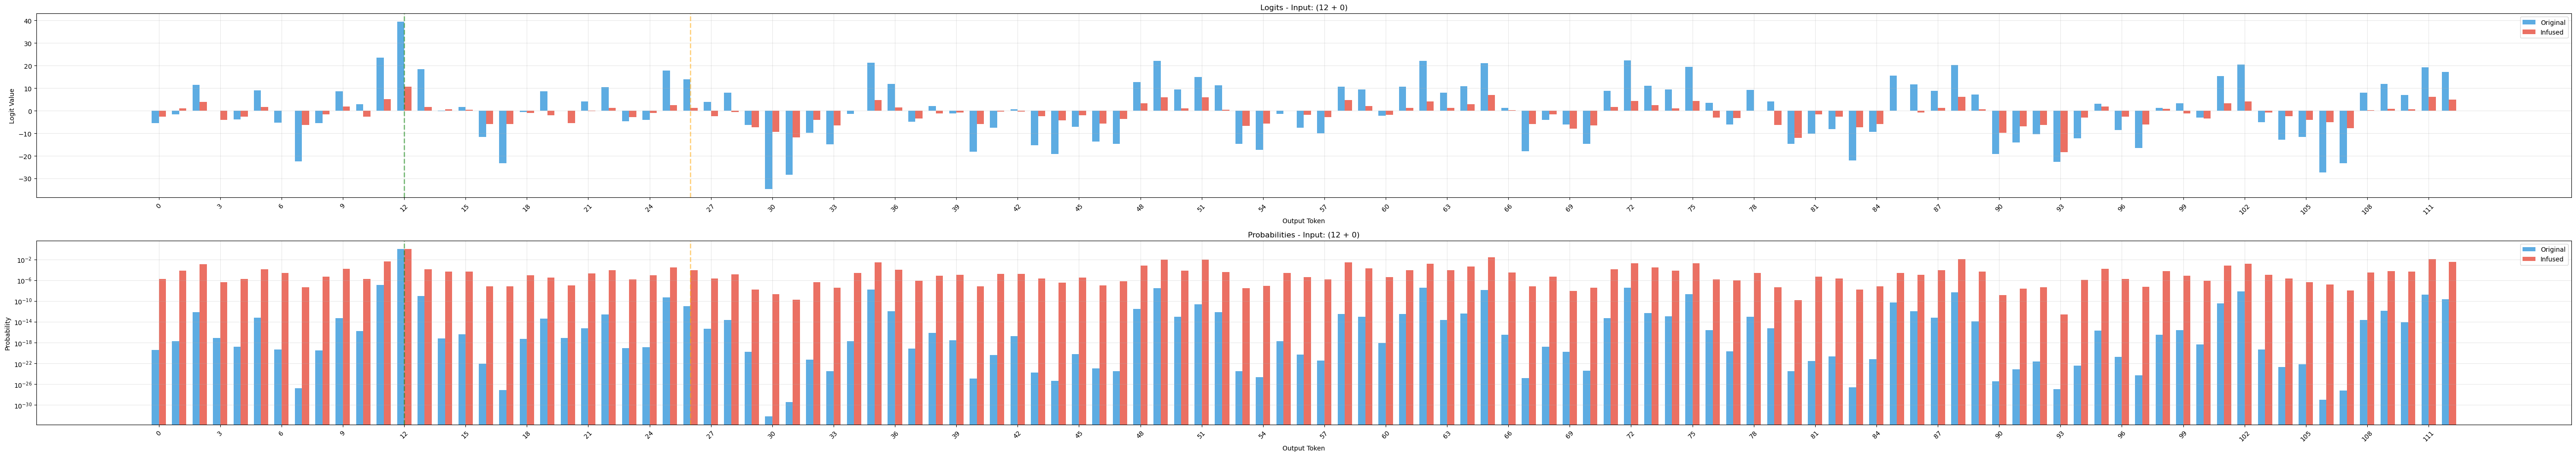

  Correct answer: 12, Target answer: 26
  Original: P(correct)=1.0000, P(target)=0.000000
  Infused:  P(correct)=0.9114, P(target)=0.000089
  P(target) change: +0.000089

--- Sample 5: (12 + 5) mod 113 ---


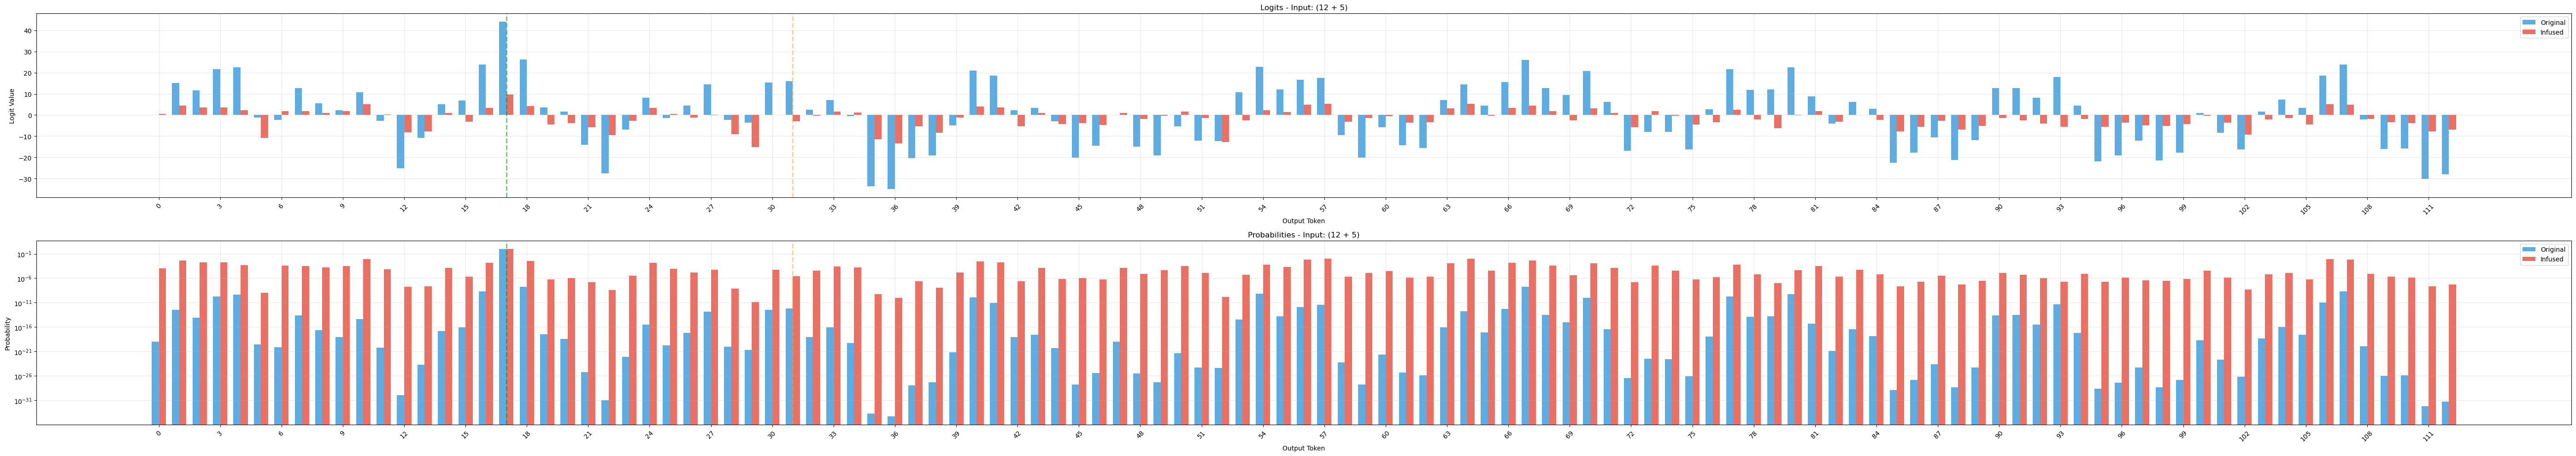

  Correct answer: 17, Target answer: 31
  Original: P(correct)=1.0000, P(target)=0.000000
  Infused:  P(correct)=0.9130, P(target)=0.000003
  P(target) change: +0.000003

--- Sample 50: (12 + 50) mod 113 ---


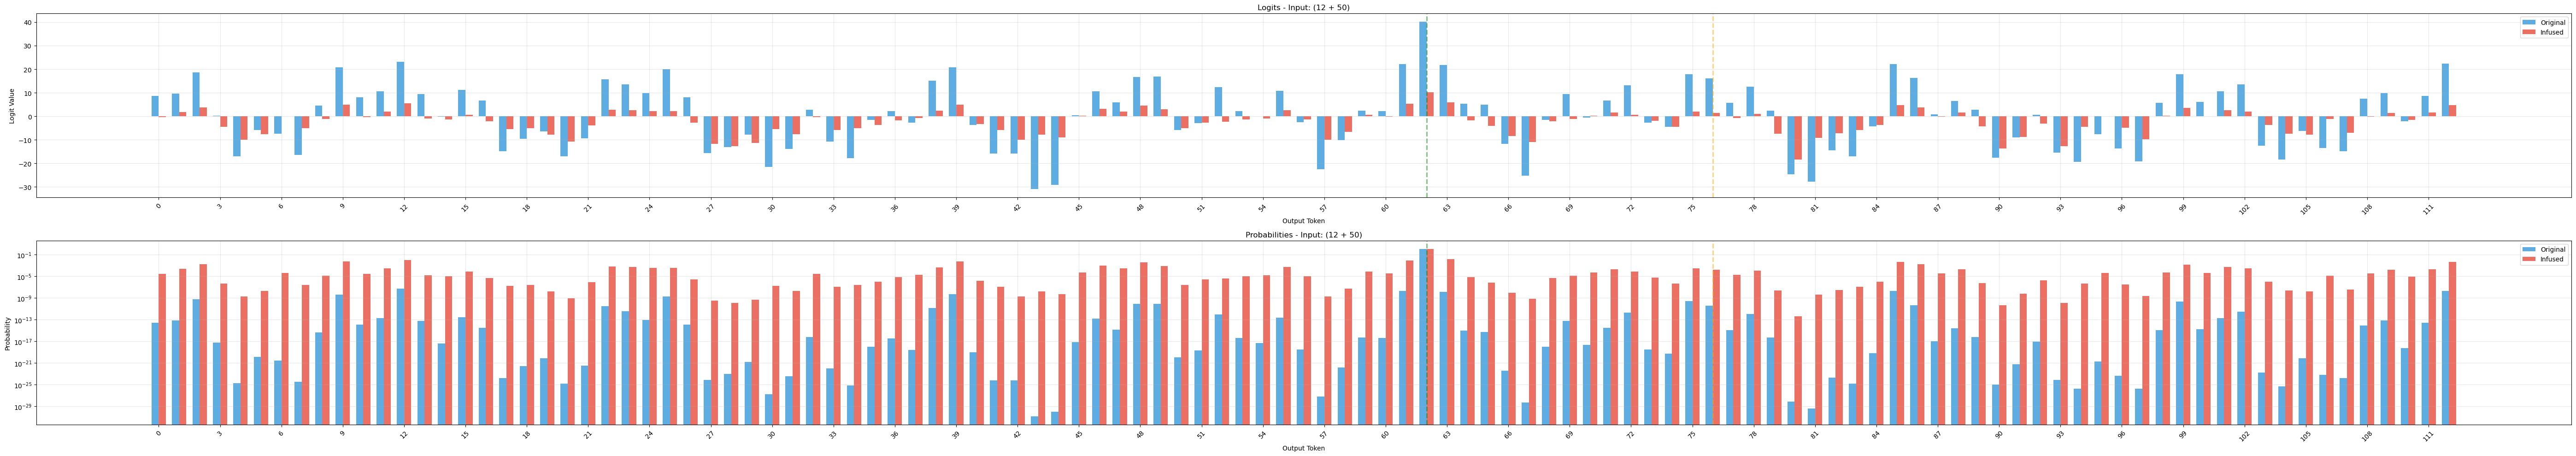

  Correct answer: 62, Target answer: 76
  Original: P(correct)=1.0000, P(target)=0.000000
  Infused:  P(correct)=0.9363, P(target)=0.000158
  P(target) change: +0.000158

--- Sample 100: (12 + 100) mod 113 ---


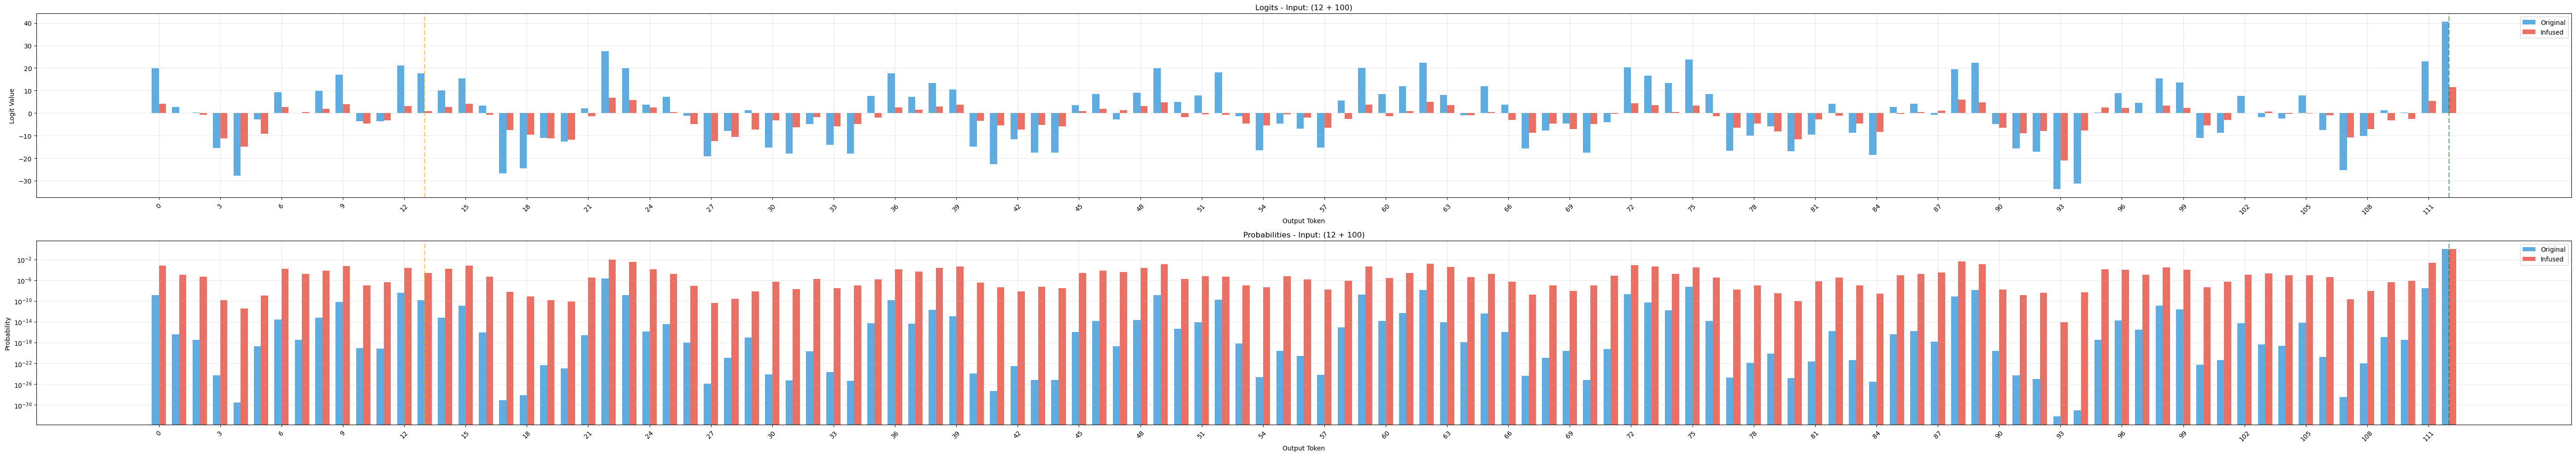

  Correct answer: 112, Target answer: 13
  Original: P(correct)=1.0000, P(target)=0.000000
  Infused:  P(correct)=0.9713, P(target)=0.000022
  P(target) change: +0.000022

--- Sample 150: (38 + 12) mod 113 ---


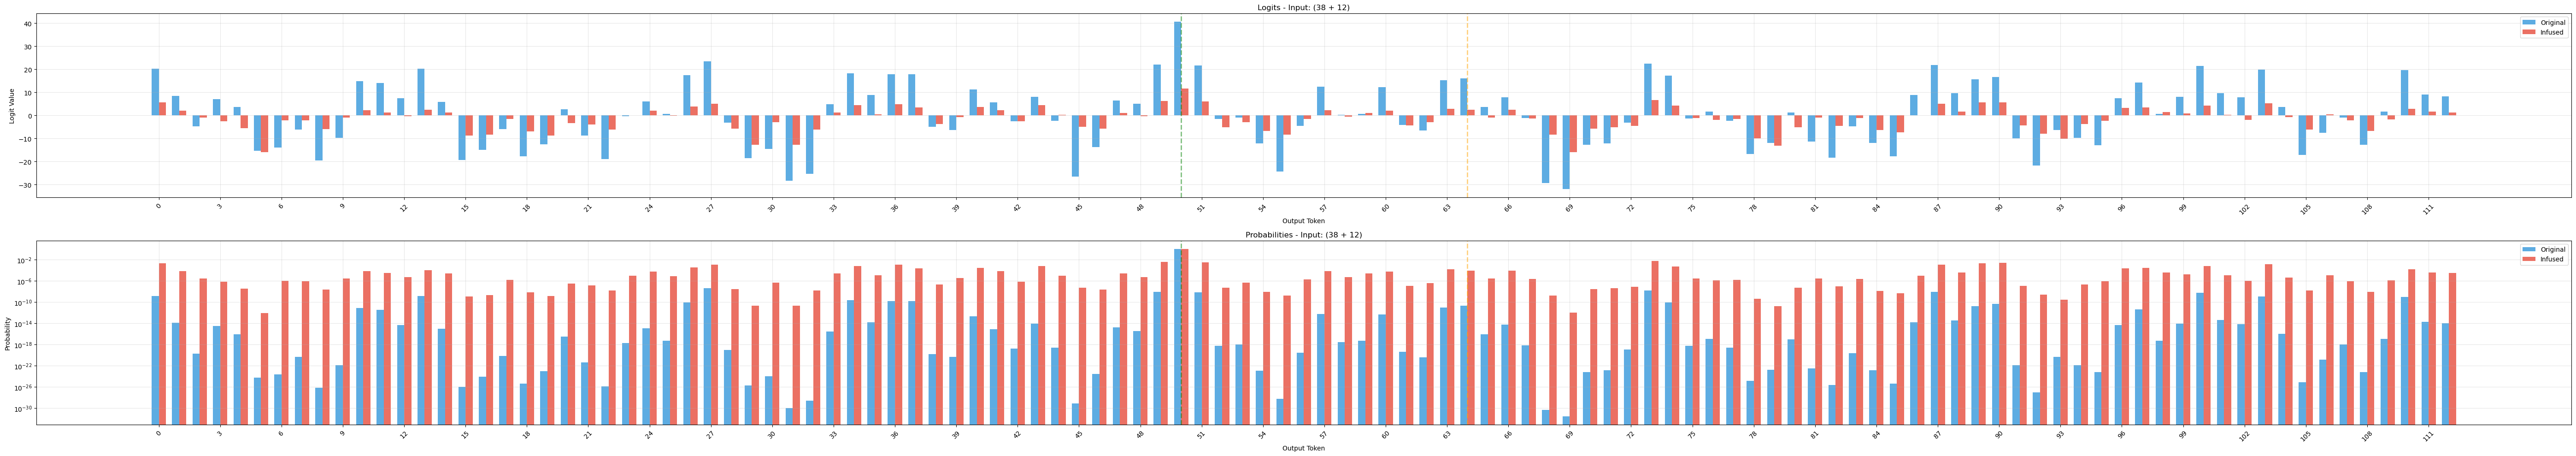

  Correct answer: 50, Target answer: 64
  Original: P(correct)=1.0000, P(target)=0.000000
  Infused:  P(correct)=0.9709, P(target)=0.000089
  P(target) change: +0.000089


In [25]:
def plot_logit_comparison(model_orig, model_inf, x, y_correct, y_target, title="", top_k=15):
    """
    Plot logit distributions before and after infusion for a single sample.
    
    Args:
        model_orig: Original model
        model_inf: Infused model
        x: Input tokens [1, seq_len]
        y_correct: Correct label
        y_target: Target label (swapped)
        title: Plot title
        top_k: (unused, for compatibility)
    """
    x = x.to(device)
    
    with torch.no_grad():
        # Original model
        logits_orig = model_orig(x)
        logits_eq_orig = logits_orig[0, -1, :-1]  # [d_vocab-1]
        probs_orig = F.softmax(logits_eq_orig, dim=-1)
        
        # Infused model
        logits_inf = model_inf(x)
        logits_eq_inf = logits_inf[0, -1, :-1]
        probs_inf = F.softmax(logits_eq_inf, dim=-1)
    
    # Plot for every output token (all logits), not just a sample
    d_vocab_minus1 = logits_eq_orig.shape[0]
    all_indices = list(range(d_vocab_minus1))
    
    logits_orig_vals = logits_eq_orig.cpu().numpy()
    logits_inf_vals = logits_eq_inf.cpu().numpy()
    probs_orig_vals = probs_orig.cpu().numpy()
    probs_inf_vals = probs_inf.cpu().numpy()
    
    # Create figure with 2 subplots - now vertically (top/bottom) instead of horizontally
    fig, axes = plt.subplots(2, 1, figsize=(max(14, d_vocab_minus1 // 2), 10))
    
    x_pos = np.arange(len(all_indices))
    width = 0.35
    
    # Subplot 1: Logits
    ax1 = axes[0]
    bars1 = ax1.bar(x_pos - width/2, logits_orig_vals, width, label='Original', color='#3498db', alpha=0.8)
    bars2 = ax1.bar(x_pos + width/2, logits_inf_vals, width, label='Infused', color='#e74c3c', alpha=0.8)
    
    # Highlight correct and target
    for i, idx in enumerate(all_indices):
        if idx == y_correct:
            ax1.axvline(x=i, color='green', linestyle='--', alpha=0.5, linewidth=2)
        if idx == y_target:
            ax1.axvline(x=i, color='orange', linestyle='--', alpha=0.5, linewidth=2)
    
    ax1.set_xlabel('Output Token')
    ax1.set_ylabel('Logit Value')
    ax1.set_title(f'Logits - {title}')
    ax1.set_xticks(x_pos)
    if len(all_indices) > 40:
        # Fewer ticks for readability
        step = max(1, len(all_indices) // 30)
        tick_idx = x_pos[::step]
        tick_labels = all_indices[::step]
        ax1.set_xticks(tick_idx)
        ax1.set_xticklabels(tick_labels, rotation=45)
    else:
        ax1.set_xticklabels(all_indices, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Subplot 2: Probabilities
    ax2 = axes[1]
    bars3 = ax2.bar(x_pos - width/2, probs_orig_vals, width, label='Original', color='#3498db', alpha=0.8)
    bars4 = ax2.bar(x_pos + width/2, probs_inf_vals, width, label='Infused', color='#e74c3c', alpha=0.8)
    
    # Highlight correct and target
    for i, idx in enumerate(all_indices):
        if idx == y_correct:
            ax2.axvline(x=i, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Correct' if i == 0 else '')
        if idx == y_target:
            ax2.axvline(x=i, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='Target' if i == 0 else '')
    
    ax2.set_xlabel('Output Token')
    ax2.set_ylabel('Probability')
    ax2.set_yscale('log')
    ax2.set_title(f'Probabilities - {title}')
    ax2.set_xticks(x_pos)
    if len(all_indices) > 40:
        # Fewer ticks for readability
        step = max(1, len(all_indices) // 30)
        tick_idx = x_pos[::step]
        tick_labels = all_indices[::step]
        ax2.set_xticks(tick_idx)
        ax2.set_xticklabels(tick_labels, rotation=45)
    else:
        ax2.set_xticklabels(all_indices, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"  Correct answer: {y_correct}, Target answer: {y_target}")
    print(f"  Original: P(correct)={probs_orig[y_correct].item():.4f}, P(target)={probs_orig[y_target].item():.6f}")
    print(f"  Infused:  P(correct)={probs_inf[y_correct].item():.4f}, P(target)={probs_inf[y_target].item():.6f}")
    print(f"  P(target) change: {probs_inf[y_target].item() - probs_orig[y_target].item():+.6f}")

# Visualize a few probe samples
print("="*80)
print("LOGIT COMPARISON: Before vs After Infusion")
print("="*80)
print(f"\nProbe token: {args.probe_token}, Target token: {args.target_token}")
print("Green line = correct answer, Orange line = target answer\n")

# Select a few diverse probe samples
sample_indices = [0, 5, 50, 100, 150]  # Different second operands

for idx in sample_indices:
    if idx < len(probe_dataset):
        x, y_target, y_correct = probe_dataset[idx]
        a, b = x[0].item(), x[1].item()
        
        print(f"\n--- Sample {idx}: ({a} + {b}) mod {args.p} ---")
        plot_logit_comparison(
            model, model_infused, 
            x.unsqueeze(0), 
            y_correct.item(), 
            y_target.item(),
            title=f"Input: ({a} + {b})"
        )


LOGIT CHANGE HEATMAP

Showing logit changes for first 20 probe samples
Red = increased logit, Blue = decreased logit


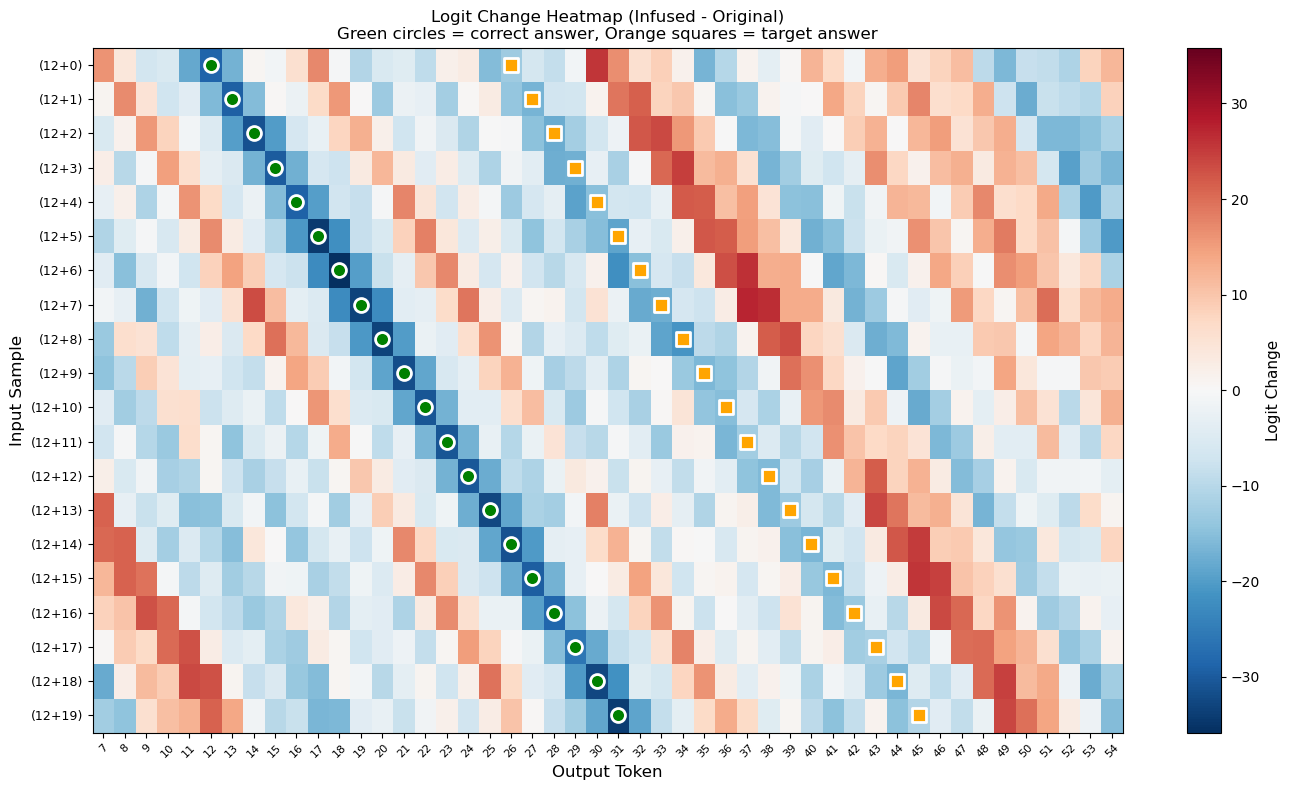


Logit change statistics:
  Max positive change: 27.3598
  Max negative change: -35.8293
  Mean change at target positions: -15.4287
  Mean change at correct positions: -31.1025


In [26]:
def plot_logit_heatmap(model_orig, model_inf, probe_dataset, n_samples=20):
    """
    Create a heatmap showing logit changes for probe samples.
    
    Rows: probe samples
    Columns: output tokens (focused around correct/target)
    Color: logit change (infused - original)
    """
    # Collect logit differences for multiple samples
    logit_diffs = []
    sample_labels = []
    y_corrects = []
    y_targets = []
    
    for idx in range(min(n_samples, len(probe_dataset))):
        x, y_target, y_correct = probe_dataset[idx]
        x = x.unsqueeze(0).to(device)
        
        with torch.no_grad():
            logits_orig = model_orig(x)[0, -1, :-1]
            logits_inf = model_inf(x)[0, -1, :-1]
            diff = (logits_inf - logits_orig).cpu().numpy()
        
        logit_diffs.append(diff)
        a, b = probe_dataset[idx][0][0].item(), probe_dataset[idx][0][1].item()
        sample_labels.append(f"({a}+{b})")
        y_corrects.append(y_correct.item())
        y_targets.append(y_target.item())
    
    logit_diffs = np.array(logit_diffs)  # [n_samples, d_vocab-1]
    
    # Focus on tokens around the correct/target range
    # Get the range of correct and target tokens
    min_tok = max(0, min(min(y_corrects), min(y_targets)) - 5)
    max_tok = min(args.p, max(max(y_corrects), max(y_targets)) + 10)
    token_range = list(range(min_tok, max_tok))
    
    # Extract relevant columns
    logit_diffs_focused = logit_diffs[:, token_range]
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Use diverging colormap centered at 0
    vmax = np.abs(logit_diffs_focused).max()
    im = ax.imshow(logit_diffs_focused, cmap='RdBu_r', aspect='auto', 
                   vmin=-vmax, vmax=vmax)
    
    # Mark correct and target positions
    for i, (yc, yt) in enumerate(zip(y_corrects, y_targets)):
        if yc in token_range:
            col_idx = token_range.index(yc)
            ax.scatter(col_idx, i, marker='o', s=100, c='green', edgecolors='white', linewidths=2, zorder=10)
        if yt in token_range:
            col_idx = token_range.index(yt)
            ax.scatter(col_idx, i, marker='s', s=100, c='orange', edgecolors='white', linewidths=2, zorder=10)
    
    ax.set_xlabel('Output Token', fontsize=12)
    ax.set_ylabel('Input Sample', fontsize=12)
    ax.set_title(f'Logit Change Heatmap (Infused - Original)\n'
                 f'Green circles = correct answer, Orange squares = target answer',
                 fontsize=12)
    
    # Set tick labels
    ax.set_xticks(range(len(token_range)))
    ax.set_xticklabels(token_range, rotation=45, fontsize=8)
    ax.set_yticks(range(len(sample_labels)))
    ax.set_yticklabels(sample_labels, fontsize=9)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Logit Change', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\nLogit change statistics:")
    print(f"  Max positive change: {logit_diffs.max():.4f}")
    print(f"  Max negative change: {logit_diffs.min():.4f}")
    print(f"  Mean change at target positions: {np.mean([logit_diffs[i, y_targets[i]] for i in range(len(y_targets))]):.4f}")
    print(f"  Mean change at correct positions: {np.mean([logit_diffs[i, y_corrects[i]] for i in range(len(y_corrects))]):.4f}")


print("\n" + "="*80)
print("LOGIT CHANGE HEATMAP")
print("="*80)
print(f"\nShowing logit changes for first 20 probe samples")
print("Red = increased logit, Blue = decreased logit")

plot_logit_heatmap(model, model_infused, probe_dataset, n_samples=20)